In [11]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import os
from matplotlib import rcParams
import matplotlib.pyplot as plt

In [2]:
rcParams["figure.figsize"] = (5, 5)

In [3]:
adata=sc.read('/projects/0/einf2548/cruiz/dmg/data/share/pHGGmap_discovery_cohort_GEX.h5ad')
adata

AnnData object with n_obs × n_vars = 397794 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'Batch_for_correction', 'Study', 'Original_annotation', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'iCNV', 'lvl_0', 'lvl_1', 'lvl_2', 'lvl_3'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'c

In [4]:
adata = adata[adata.obs['lvl_2'].isin(['Developmental_like','Reactive_like','Myeloid'])].copy()
adata

AnnData object with n_obs × n_vars = 335011 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'Batch_for_correction', 'Study', 'Original_annotation', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'Survival', 'Survival_months', 'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA', 'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'ASXL1', 'BCOR', 'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'ACVR1', 'TSHR', 'BRAF', 'GNAQ', 'LMNA', 'KIT', 'ARID1A', 'KRAS', 'Other', 'iCNV', 'lvl_0', 'lvl_1', 'lvl_2', 'lvl_3'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std', 'c

In [ ]:
tmp = adata.copy()
tmp.X = tmp.layers["counts"]
sc.pp.scale(tmp)
adata.layers["scaled"] = tmp.X

In [ ]:
genes = ["FTL","FTH1","GPX4","PRDX1",
  "VIM","ACTB","TUBA1B","CFL1",
  "HSP90AB1","CRYAB","UBB",
  "APOE","MIF","CST3"]

dp = sc.pl.dotplot(adata, genes, groupby='lvl_3', return_fig=True,
             layer='scaled', vmin=-1, vmax=1, swap_axes= True, dendrogram=False)
dp.style(color_on='square', cmap='RdBu_r', dot_edge_color=None, dot_edge_lw=None, size_exponent=1.5)\
.add_totals().show()

In [ ]:
cols_to_drop = [
    'H3F3A', 'H3C3', 'HIST1H3B', 'HIST2H3C', 'TP53', 'EGFR', 'PDGFRA',
    'SUFU', 'NF1', 'pTERT', 'PIK3CA', 'PIK3R1', 'ATRX', 'PTEN', 'BCOR',
    'BCORL1', 'SMC1A', 'WT1', 'PPM1D', 'TSHR', 'BRAF', 'GNAQ', 'LMNA',
    'KIT', 'KRAS'
]

adata.obs = adata.obs.drop(columns=[c for c in cols_to_drop if c in adata.obs.columns])

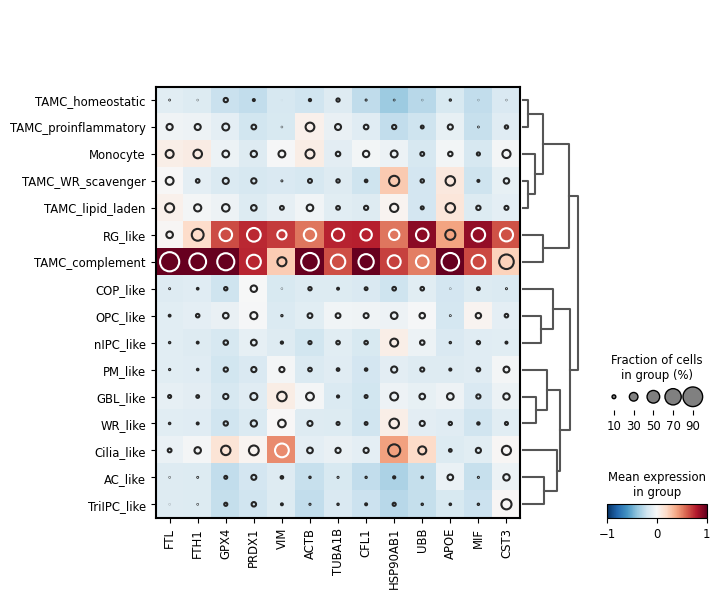

In [48]:
# computes dendrogram for the groupby using only your gene panel
# sc.tl.dendrogram(adata, groupby="lvl_3", var_names=genes_present)

genes = ["FTL","FTH1","GPX4","PRDX1",
  "VIM","ACTB","TUBA1B","CFL1",
  "HSP90AB1","UBB",
  "APOE","MIF","CST3"]

dp = sc.pl.dotplot(
    adata, genes, groupby="lvl_3",
    layer="scaled", vmin=-1, vmax=1, swap_axes=False,
    dendrogram=True, return_fig=True
)
dp.style(color_on="square", cmap="RdBu_r", dot_edge_color=None,
         dot_edge_lw=None, size_exponent=1.5).savefig('figures/dotplot_overlap_genes_rg_and_complement.pdf')

In [16]:
adata=sc.read('/projects/0/einf2548/cruiz/dmg/data/dmg_ascites_prettx_posttx.h5ad')
adata

AnnData object with n_obs × n_vars = 19804 × 22096
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'batch', 'sample', 'stage'
    var: 'name'
    obsm: 'X_mnn', 'X_umap'

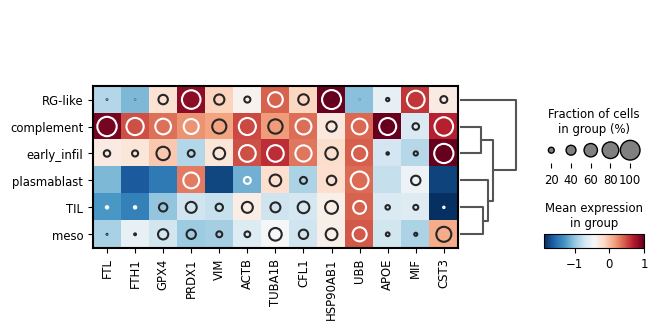

In [21]:
genes = ["FTL","FTH1","GPX4","PRDX1",
  "VIM","ACTB","TUBA1B","CFL1",
  "HSP90AB1","UBB",
  "APOE","MIF","CST3"]

sc.tl.dendrogram(adata, groupby="cluster_annot", var_names=genes)

dp = sc.pl.dotplot(
    adata, genes, groupby="cluster_annot",
    layer="scaled", swap_axes=False,vmax=1,
    dendrogram=True, return_fig=True
)
dp.style(color_on="square", cmap="RdBu_r", dot_edge_color=None,
         dot_edge_lw=None, size_exponent=1.5).savefig('figures/dotplot_overlap_genes_rg_and_complement_ascites.pdf')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "/projects/0/einf2548/cruiz/dmg/data/Supplementary tables.xlsx"
s3 = pd.read_excel(path, sheet_name="S3")  # malignant programs
s5 = pd.read_excel(path, sheet_name="S5")  # myeloid programs

malignant_names = {
    "MP_1":"Cell cycle","MP_2":"OPC-like","MP_3":"AC-like","MP_4":"RG-like",
    "MP_5":"COP-like","MP_6":"Hypoxia","MP_7":"PM-like",
    "MP_8":"Cilia-like","MP_9":"WR-like","MP_10":"Stress",
    "MP_11":"TriIPC-like","MP_12":"nIPC-like","MP_13":"GBL-like"
}
myeloid_names = {
    "MP_1":"Cell cycle","MP_2":"Complement","MP_3":"Hypoxia","MP_4":"Monocyte",
    "MP_5":"Glial-enriched","MP_6":"Synaptic pruning","MP_7":"Proinflammatory",
    "MP_8":"Phagocytic scavenger","MP_9":"Lipid-laden","MP_10":"Microglia (homeostatic)",
    "MP_11":"Stress","MP_12":"Cell projection/junction","MP_13":"Unassigned"
}

sig3 = {col:set(s3[col].dropna().astype(str)) for col in s3.columns}
sig5 = {col:set(s5[col].dropna().astype(str)) for col in s5.columns}

rows=[]
for c3,g3 in sig3.items():
    for c5,g5 in sig5.items():
        inter=len(g3 & g5)
        union=len(g3 | g5)
        jacc = inter/union if union else 0.0
        cover3 = inter/len(g3) if len(g3) else 0.0
        cover5 = inter/len(g5) if len(g5) else 0.0
        rows.append((c3,c5,inter,jacc,cover3,cover5))

df = pd.DataFrame(rows, columns=["S3_MP","S5_MP","overlap","jaccard","cover_S3","cover_S5"])
df["S3_name"] = df["S3_MP"].map(malignant_names)
df["S5_name"] = df["S5_MP"].map(myeloid_names)

def pivot_metric(metric):
    mat = df.pivot(index="S3_name", columns="S5_name", values=metric).fillna(0)
    mat = mat.loc[mat.max(axis=1).sort_values(ascending=False).index]
    return mat

mat_counts  = pivot_metric("overlap")
mat_jaccard = pivot_metric("jaccard")

def plot_heatmap(matrix, title, cbar_label, outpng=None):
    import numpy as np
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(matrix.values, aspect='auto')
    ax.set_xticks(np.arange(matrix.shape[1])); ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(matrix.shape[0])); ax.set_yticklabels(matrix.index)
    cb = plt.colorbar(im, ax=ax); cb.set_label(cbar_label)
    ax.set_title(title); plt.tight_layout()
    if outpng: fig.savefig(outpng, dpi=200, bbox_inches="tight")
    return fig

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
from scipy.stats import hypergeom

rows = []
for c3, g3 in sig3.items():
    for c5, g5 in sig5.items():
        inter = len(g3 & g5)
        union = len(g3 | g5)
        jacc  = inter/union if union else 0.0
        rows.append((c3, c5, inter, jacc, len(g3), len(g5)))

df = pd.DataFrame(rows, columns=["S3_MP","S5_MP","overlap","jaccard","size_S3","size_S5"])
df["S3_name"] = df["S3_MP"].map(malignant_names).fillna(df["S3_MP"])
df["S5_name"] = df["S5_MP"].map(myeloid_names).fillna(df["S5_MP"])

mat_jacc = df.pivot(index="S3_name", columns="S5_name", values="jaccard").fillna(0.0)
mat_cnt  = df.pivot(index="S3_name", columns="S5_name", values="overlap").fillna(0)

universe = set().union(*sig3.values()).union(*sig5.values())
M = len(universe)  # population size

def hypergeom_pval(k, n, N, M):
    # k=overlap, n=len(sig3), N=len(sig5), M=universe size
    # one-sided: P(X >= k)
    rv = hypergeom(M, n, N)
    # sf is 1-cdf, but sf(k-1) gives P(X>=k)
    return rv.sf(k-1) if k > 0 else 1.0

df["pval"] = df.apply(lambda r: hypergeom_pval(r["overlap"], r["size_S3"], r["size_S5"], M), axis=1)

# Benjamini–Hochberg FDR
df = df.sort_values("pval")
m = len(df)
df["rank"] = np.arange(1, m+1)
df["fdr"]  = (df["pval"] * m / df["rank"]).clip(upper=1.0)
df = df.sort_values(["S3_name","S5_name"]).reset_index(drop=True)

# Also build an FDR matrix aligned with mat_jacc
mat_fdr = df.pivot(index="S3_name", columns="S5_name", values="fdr").reindex(index=mat_jacc.index, columns=mat_jacc.columns)

# Use correlation distance on rows/cols of the Jaccard matrix
def cluster_order(matrix, axis=0, method="average"):
    X = matrix.values if axis==0 else matrix.values.T
    # pdist with 'correlation' gives 1 - Pearson correlation
    d = pdist(X, metric="correlation")
    # If rows/cols are constant (rare), correlation may be nan; replace with 0
    d = np.nan_to_num(d, nan=0.0)
    Z = linkage(d, method=method)
    leaves = dendrogram(Z, no_plot=True)["leaves"]
    return leaves

row_order = cluster_order(mat_jacc, axis=0)
col_order = cluster_order(mat_jacc, axis=1)

mat_jacc_cl = mat_jacc.iloc[row_order, :].iloc[:, col_order]
mat_fdr_cl  = mat_fdr.iloc[row_order, :].iloc[:, col_order]

# ---------- PLOT (clustered) ----------
def plot_clustered_jaccard(jacc_mat, fdr_mat=None, alpha_sig=0.05, annotate_sig=True):
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(jacc_mat.values, aspect='auto', cmap='Oranges', vmin=0, vmax=jacc_mat.values.max())
    ax.set_xticks(np.arange(jacc_mat.shape[1])); ax.set_xticklabels(jacc_mat.columns, rotation=45, ha='right')
    ax.set_yticks(np.arange(jacc_mat.shape[0])); ax.set_yticklabels(jacc_mat.index)
    cb = plt.colorbar(im, ax=ax); cb.set_label("Jaccard")

    # Optional: mark significant overlaps
    if annotate_sig and fdr_mat is not None:
        sig = (fdr_mat.values < alpha_sig)
        for i in range(jacc_mat.shape[0]):
            for j in range(jacc_mat.shape[1]):
                if sig[i, j]:
                    ax.text(j, i, "•", ha="center", va="center")  

    ax.set_title("Malignant vs Myeloid — Jaccard (clustered)")
    plt.tight_layout()
    return fig

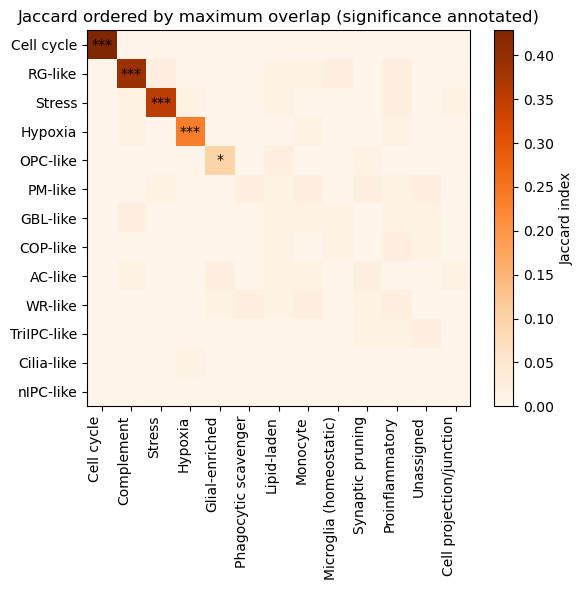

In [3]:
row_order = mat_jacc.max(axis=1).sort_values(ascending=False).index
col_order = mat_jacc.max(axis=0).sort_values(ascending=False).index

J = mat_jacc.loc[row_order, col_order]
F = mat_fdr.loc[row_order, col_order]

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(J.values, aspect='auto', cmap='Oranges', vmin=0, vmax=J.values.max())

ax.set_xticks(np.arange(J.shape[1]))
ax.set_xticklabels(J.columns, rotation=90, ha='right')

ax.set_yticks(np.arange(J.shape[0]))
ax.set_yticklabels(J.index)

cb = plt.colorbar(im, ax=ax)
cb.set_label("Jaccard index")

for i in range(J.shape[0]):
    for j in range(J.shape[1]):
        f = F.iat[i, j]
        if f < 0.001:
            mark = "***"
        elif f < 0.01:
            mark = "**"
        elif f < 0.05:
            mark = "*"
        else:
            mark = ""

        if mark:
            ax.text(j, i, mark, ha="center", va="center", fontsize=10, color="black")

ax.set_title("Jaccard ordered by maximum overlap (significance annotated)")
plt.tight_layout()
plt.show()